In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import skyfield
from skyfield.api import Star, load, wgs84
from skyfield.data import hipparcos

In [6]:
def get_limiting_magnitude(target_lat, target_lon, csv_path='GaN2024.csv'):
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['SQMReading', 'Latitude', 'Longitude'])
    df = df[df['SQMReading'] > 15]
    df = df[df['SQMReading'] < 23]
    df['distance'] = np.sqrt(
        (df['Latitude'] - target_lat)**2 + 
        (df['Longitude'] - target_lon)**2
    )
    nearest_row = df.loc[df['distance'].idxmin()]
    print(f"Nearest data point is {nearest_row['distance']:.2f} degrees away.")
    print(f"Local Sky Brightness (SQM): {nearest_row['SQMReading']}")
    nelm = ((nearest_row['SQMReading'] - 8.89) / 2) + 0.5
    print(f"NELM: {nelm}")
    return nelm

def find_visible_stars(lat, lon, limiting_mag):
    with load.open(hipparcos.URL) as f:
        df_stars = hipparcos.load_dataframe(f)
    bright_stars = df_stars[df_stars['magnitude'] <= limiting_mag]
    ts = load.timescale()
    t = ts.now()
    planets = load('de421.bsp')
    earth = planets['earth']
    observer = earth + wgs84.latlon(latitude_degrees=lat, longitude_degrees=lon)
    stars = Star.from_dataframe(bright_stars)
    astrometric = observer.at(t).observe(stars)
    alt, az, distance = astrometric.apparent().altaz()
    visible_mask = alt.degrees > 0
    visible_stars = bright_stars[visible_mask]
    return visible_stars[['magnitude', 'ra_degrees', 'dec_degrees']]

NameError: name 'earth' is not defined

Nearest data point is 0.54 degrees away.
Local Sky Brightness (SQM): 15.59
NELM: 3.8499999999999996


[Text(0.5, 1.0, 'The Night Sky'),
 Text(0.5, 0, 'Right ascension (h)'),
 Text(0, 0.5, 'Declination (°)')]

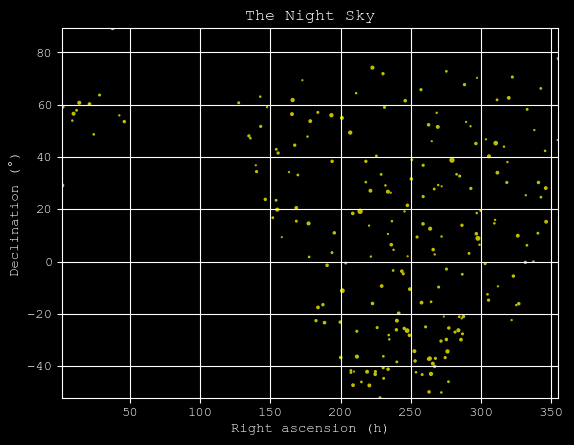

In [4]:
latitude = 34.0967
longitude = -117.7198
nelm = get_limiting_magnitude(latitude, longitude,'GaN2024.csv')
visible_stars = find_visible_stars(latitude, longitude, nelm)

fig, ax = plt.subplots()
plt.style.use("dark_background")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Courier New']
ax.scatter(visible_stars['ra_degrees'], visible_stars['dec_degrees'], 8 - (visible_stars['magnitude']) * 2, 'y')
ax.set_xlim(visible_stars['ra_degrees'].min(), visible_stars['ra_degrees'].max())
ax.set_ylim(visible_stars['dec_degrees'].min(), visible_stars['dec_degrees'].max())
ax.grid(True)
ax.set(title='The Night Sky',
       xlabel='Right ascension (h)', ylabel='Declination (°)')

In [9]:
def find_visible_stars(lat, lon, limiting_mag):
    with load.open(hipparcos.URL) as f:
        df_stars = hipparcos.load_dataframe(f)
    bright_stars = df_stars[df_stars['magnitude'] <= limiting_mag]
    ts = load.timescale()
    t = ts.now()
    planets = load('de421.bsp')
    earth = planets['earth']
    observer = earth + wgs84.latlon(latitude_degrees=lat, longitude_degrees=lon)
    stars = Star.from_dataframe(bright_stars)
    astrometric = observer.at(t).observe(stars)
    alt, az, distance = astrometric.apparent().altaz()
    visible_mask = alt.degrees > 0
    visible_stars = bright_stars[visible_mask]
    return visible_stars[['magnitude', 'ra_degrees', 'dec_degrees']]

# Converting from RA, Dec to alt, az
lat = 
astrometric = (earth + observer).at(t).observe(stars)
apparent = astrometric.apparent()
alt, az, distance = apparent.altaz()

# Add alt, az to the old data frame
df['altitude_degrees'] = alt.degrees
df['azimuth_degrees'] = az.degrees
stars_above_horizon = df[df['altitude_degrees'] >= 0].copy()

NameError: name 'observer' is not defined